# Preprocessing - Projet Alzheimer 

**Objectif** : Transformer les données brutes en features ML prêtes pour la modélisation

**Dataset** : ADNI  (Alzheimer's Disease Neuroimaging Initiative)

**Date** : 27 avril 2026



## 1. Import des librairies

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


from supabase import create_client
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split



## 2. Paramétrages divers

In [2]:
#pour visualiser toutes la données en ligne et en colonne
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 3. Chargement des données

In [3]:
# récupération des mots de passe et URL
url = os.environ.get("SUPABASE_URL")
key = os.environ.get("SUPABASE_SERVICE_ROLE_KEY")
 
# connexion
supabase = create_client(url, key)
 
# récupération de toutes les lignes
batch_size = 1000
start = 0
rows = []

while True:
    end = start + batch_size - 1
    batch = supabase.table("ALZ_BRONZE").select("*").range(start, end).execute()

    if not batch.data:
        break

    rows.extend(batch.data)
    start += batch_size

# transformation en DataFrame
dfB = pd.DataFrame(rows)

print("Données chargées.")
print(f'  • Dimensions: {dfB.shape[0]:,} lignes × {dfB.shape[1]} colonnes')
print(f'  • Mémoire utilisée: {dfB.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'  • Types: {dfB.dtypes.value_counts().to_dict()}')
print(f'  • Valeurs manquantes: {dfB.isnull().sum().sum():,}')

Données chargées.
  • Dimensions: 15,987 lignes × 584 colonnes
  • Mémoire utilisée: 99.5 MB
  • Types: {dtype('float64'): 526, <StringDtype(storage='python', na_value=nan)>: 54, dtype('int64'): 4}
  • Valeurs manquantes: 5,095,662


## 4. Filtre recommandation ADNI

In [19]:
#Filtrage ADNI recommandé
df = dfB.copy()
df = df[~df["PTID"].str.startswith("381_S_10", na=False)]

lignes_dfB = len(dfB)
lignes_df= len(df)
Filtre_ADNI=lignes_dfB-lignes_df

print(f'  • Nombre de lignes supprimées sur recommandation ADNI : {Filtre_ADNI}')
print(f'  • Nombre de lignes restantes : {df.shape[0]}')

  • Nombre de lignes supprimées sur recommandation ADNI : 135
  • Nombre de lignes restantes : 15852


## 5. Traitement des valeurs aberrantes codées par ADNI

In [20]:
nan_avant = df.isnull().sum().sum()

df = df.replace([-4, -1,9999], np.nan)

nan_après = df.isnull().sum().sum()

print(f'\n Codes ADNI nan remplacés:')
print(f'  • Avant: {nan_avant:,} valeurs manquantes')
print(f'  • Après: {nan_après:,} valeurs manquantes')
print(f'  • Nan ADNI encodés : { nan_après- nan_avant:,}')
print(f'  • Pourcentage de nan ADNI : {((nan_avant - nan_après) / df.size) * 100:.2f}%')



 Codes ADNI nan remplacés:
  • Avant: 5,049,469 valeurs manquantes
  • Après: 5,133,884 valeurs manquantes
  • Nan ADNI encodés : 84,415
  • Pourcentage de nan ADNI : -0.91%


## 6. Transformation

In [21]:
Distribution_Acible=(df["DIAGNOSIS"].value_counts(normalize=True)*100).round(2)

df["DIAGNOSIS"] = df["DIAGNOSIS"].apply(lambda x: 0 if x == 1 else (1 if x in [2, 3] else x))
Distribution_Ncible=(df["DIAGNOSIS"].value_counts(normalize=True)*100).round(2)

print(f'  • Distribution de l\'ancienne cible : {Distribution_Acible}')
print(f'  • Distribution de la nouvelle cible : {Distribution_Ncible}')


  • Distribution de l'ancienne cible : DIAGNOSIS
2    41.09
1    40.08
3    18.84
Name: proportion, dtype: float64
  • Distribution de la nouvelle cible : DIAGNOSIS
1    59.92
0    40.08
Name: proportion, dtype: float64


In [22]:
#Conversion du poids en kg celon l'unité
print(f'    • Moyenne du poids avant transformation : {df["VSWEIGHT"].mean():.2f}')

df["VSWEIGHT"] = df["VSWEIGHT"] / np.where(df["VSWTUNIT"] == 1, 2.20462, 1)
df["VSWEIGHT"] = df["VSWEIGHT"].round(0)

print(f'    • Moyenne du poids en kg après transformation : {df["VSWEIGHT"].mean():.2f}')


    • Moyenne du poids avant transformation : 148.82
    • Moyenne du poids en kg après transformation : 77.14


In [23]:
#Conversion de la taille en cm celon l'unité
print(f'    • Moyenne de la taille avant transformation : {df["VSHEIGHT"].mean():.2f}')

df["VSHEIGHT"] = df["VSHEIGHT"] * np.where(df["VSHTUNIT"]==1, 2.54, 1)
df["VSHEIGHT"] = df["VSHEIGHT"].round(0)

print(f'    • Moyenne de la taille en cm après transformation : {df["VSHEIGHT"].mean():.2f}')


    • Moyenne de la taille avant transformation : 103.83
    • Moyenne de la taille en cm après transformation : 168.81


In [24]:
#suppression des lignes sans unités
lignes_df= len(df)
df = df[~((df["VSHEIGHT"].notna()) & (df["VSHTUNIT"].isna()))]
df = df[~((df["VSWEIGHT"].notna()) & (df["VSWTUNIT"].isna()))]
lignes_dfSansUnit= len(df)
NbLigSansUnit=lignes_df-lignes_dfSansUnit

print(f'  • Nombre de lignes supprimées sans unités : {NbLigSansUnit}')
print(f'  • Nombre de lignes restantes : {df.shape[0]}')

  • Nombre de lignes supprimées sans unités : 5
  • Nombre de lignes restantes : 15847


## 7. Sélection des variables step 1 métier

In [25]:
#VSWTUNIT : 1=pounds et 2=kilogramme colonne VSWEIGHT à convertir en kilogramme toutes les unités 1 de la VSWTUNIT (/2.20462)
#VSHTUNIT : 1=inches; 2=centimeters	colonne VSHEIGHT à convertir en cm toutes les unités 1 de VSHTUNIT (*2.54)
cols = ['DIAGNOSIS','PTGENDER','PTEDUCAT','PTMARRY','PTHAND','MMSCORE','CDRSB','CDGLOBAL','CDMEMORY','CDJUDGE','CDCOMMUN','CDHOME','CDCARE','TOTSCORE','TOTAL13','WORD2DL','WORD1DL','VSWEIGHT','VSHEIGHT','VSBPSYS','VSBPDIA','VSPULSE','ST101SV','ST112SV','ST120SV','ST125SV','MH4CARD','MH9ENDO','MH14ALCH','MH16SMOK','MH2NEURL','MHPSYCH','MH11HEMA','MH6HEPAT']

df = df[cols]

print(f'  • Sélection des {df[cols].shape[1]} variables celon les recommandation métier')

  • Sélection des 34 variables celon les recommandation métier


## 8. Imputation des valeurs manquantes

In [26]:

categorical_cols=['DIAGNOSIS','PTGENDER','PTMARRY','PTHAND','CDCARE','WORD2DL','WORD1DL','MH4CARD','MH9ENDO','MH14ALCH','MH16SMOK','MH2NEURL','MHPSYCH','MH11HEMA','MH6HEPAT']
df[categorical_cols] = df[categorical_cols].astype('category')

numeric_cols=['PTEDUCAT','MMSCORE','CDRSB','CDGLOBAL','CDMEMORY','CDJUDGE','CDCOMMUN','CDHOME','TOTSCORE','TOTAL13','VSWEIGHT','VSHEIGHT','VSBPSYS','VSBPDIA','VSPULSE','ST101SV','ST112SV','ST120SV','ST125SV']

# Statistiques avant imputation
print(f'\n Avant imputation:')
missing_before = df.isnull().sum()
print(f'  • Total valeurs manquantes: {missing_before.sum():,}')

imputer_med = SimpleImputer(strategy='median')
df[numeric_cols] = imputer_med.fit_transform(df[numeric_cols])

imputer_mode = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_mode.fit_transform(df[categorical_cols])


print(f'\n Après imputation:')
missing_after = df.isnull().sum().sum()
print(f'  • Total valeurs manquantes: {missing_after:,}')
print(f'  • Réduction: {missing_before.sum() - missing_after:,} valeurs imputes')
print(f'  • Stratégie numérique: Mediane des {df[numeric_cols].shape[1]} variables quantitatives')
print(f'  • Stratégie catégorique: Mode (la plus fréquente) des {df[categorical_cols].shape[1]} variables qualitatives')


 Avant imputation:
  • Total valeurs manquantes: 246,556

 Après imputation:
  • Total valeurs manquantes: 0
  • Réduction: 246,556 valeurs imputes
  • Stratégie numérique: Mediane des 19 variables quantitatives
  • Stratégie catégorique: Mode (la plus fréquente) des 15 variables qualitatives


## 9. Feature engineering

In [27]:
# IMC poids/taille en m
df['IMC'] = df['VSWEIGHT'] / ((df['VSHEIGHT']/100) ** 2)
print(f'  • Indice de masse corporelle = poids / (taille en metre)^2')
print(f'    Range : [{df["IMC"].min():.1f}, {df["IMC"].max():.1f}]')
print(f'    Moyenne : {df["IMC"].mean():.1f}')

  • Indice de masse corporelle = poids / (taille en metre)^2
    Range : [2.8, 331.9]
    Moyenne : 27.4


In [28]:
#en mmHg ratio tension artérielle : Systolique /Diastolique 
df['RtensionA'] = df['VSBPSYS'] / df['VSBPDIA']
print(f'  • Ratio tension artérielle = systolic / diastolic')
print(f'    Range : [{df["RtensionA"].min():.2f}, {df["RtensionA"].max():.2f}]')
print(f'    Moyenne : {df["RtensionA"].mean():.2f}')

  • Ratio tension artérielle = systolic / diastolic
    Range : [0.57, 4.82]
    Moyenne : 1.82


In [29]:
#en mmHg pression pulsée : Systolique−Diastolique
df['pressionP'] = df['VSBPSYS'] - df['VSBPDIA']
print(f'  • Pression pulsée = systolic - diastolic')
print(f'    Range : [{df["pressionP"].min():.1f}, {df["pressionP"].max():.1f}]')
print(f'    Moyenne : {df["pressionP"].mean():.1f}')

  • Pression pulsée = systolic - diastolic
    Range : [-55.0, 152.0]
    Moyenne : 59.6


## 10. Nettoyage des doublons

In [30]:
#suppression des lignes doubles
lignes_df= len(df)

df = df.drop_duplicates()
lignes_dfDouble= len(df)
NbLigDouble=lignes_df-lignes_dfDouble

print(f'  • Nombre de lignes doubles : {NbLigDouble}')
print(f'  • Nombre de lignes restantes : {df.shape[0]}')



  • Nombre de lignes doubles : 315
  • Nombre de lignes restantes : 15532


## 11. Normalisation

In [31]:
numeric_cols.extend(['IMC', 'RtensionA', 'pressionP'])
numeric_to_scale = df[numeric_cols].columns.tolist()

print(f'\n Features à normaliser: {len(numeric_to_scale)}')

scaler = StandardScaler()
df[numeric_to_scale] = scaler.fit_transform(df[numeric_to_scale])

print(f'\n Après StandardScaler:')
print(f'  • Moyenne: {df[numeric_to_scale].mean().mean():.6f} (≈ 0)')
print(f'  • Std: {df[numeric_to_scale].std().mean():.6f} (≈ 1)')
print(f'  • Min: {df[numeric_to_scale].min().min():.2f}')
print(f'  • Max: {df[numeric_to_scale].max().max():.2f}')


 Features à normaliser: 22

 Après StandardScaler:
  • Moyenne: 0.000000 (≈ 0)
  • Std: 1.000032 (≈ 1)
  • Min: -11.80
  • Max: 44.49


## 12. Encodage 
La variable ordinale 'CDCARE' est déjà encodées en chiffres.<br>
CDCARE autonomie dans les soins personnels :<br>
0 → fonctionnement normal<br>
1 → altération légère<br>
2 → altération modérée<br>
3 → altération sévère<br>

OrdinalEncoder ne change pas l'ordre il change du texte en chiffre (selon un ordre choisi).

In [18]:
ordinale_cols=['CDCARE' ]
for col in ordinale_cols:
    print(col, ":", df[col].unique())

print(f'  • Variable(s) ordinale(s) {df[ordinale_cols].shape[1]} déjà encodées.')


CDCARE : [0. 1. 2. 3.]
  • Variable(s) ordinale(s) 1 déjà encodées.


Les variables nominales sont déjà encodées en chiffres, mais nous devons enlever la notion d'ordre. Nous utiliserons Onhotencoder.<br>

PTMARRY : <br>
1 → Marié <br>
2 → Veuf / Veuve <br>
3 → Divorcé <br>
4 → Jamais marié <br>
5 → Inconnu <br>
6 → Union libre déclarée <br>

PTGENDER : <br> 1 → Homme <br> 2 → Femme <br>

PTHAND : <br> 1 → droite <br> 2 → gauche <br>



In [19]:
nominale_cols=['PTGENDER','PTMARRY','PTHAND']
for col in nominale_cols:
    print(col, ":", df[col].unique())

print(f'  • Variable(s) nominale(s) {df[nominale_cols].shape[1]} à encoder avec OneHotEncoder.')


PTGENDER : [2. 1.]
PTMARRY : [1. 2. 3. 4. 5. 6.]
PTHAND : [1. 2.]
  • Variable(s) nominale(s) 3 à encoder avec OneHotEncoder.


In [20]:
NbVariableSOneHotEncoder = df.shape[1]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df[nominale_cols])

encoded_cols = encoder.get_feature_names_out(nominale_cols)
df_encoded = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

df = df.drop(columns=nominale_cols)
df = pd.concat([df, df_encoded], axis=1)

print(f' • Variable(s) nominale(s) encodés avec OneHotEncoder : {len(nominale_cols)}')
print(f' • Total variables {df.shape[1]} avec colonnes OneHotEncoder.')

 • Variable(s) nominale(s) encodés avec OneHotEncoder : 3
 • Total variables 44 avec colonnes OneHotEncoder.


Les variables binaire sont déjà encodées : 'WORD2DL','WORD1DL','MH4CARD','MH9ENDO','MH14ALCH','MH16SMOK','MH2NEURL','MHPSYCH','MH11HEMA','MH6HEPAT'

WORD1DL, WORD2DL : 0=Incorrect ; 1=Correct

MH4CARD, MH9ENDO, MH14ALCH, MH16SMOK, MH2NEURL, MHPSYCH, MH11HEMA, MH6HEPAT : ,1=Oui ; 0=Non

In [21]:
binaire_cols=['WORD2DL','WORD1DL','MH4CARD','MH9ENDO','MH14ALCH','MH16SMOK','MH2NEURL','MHPSYCH','MH11HEMA','MH6HEPAT']
for col in binaire_cols:
    print(col, ":", df[col].unique())

print(f'  • Variable(s) binaire(s) {df[binaire_cols].shape[1]} déjà encodées.')

WORD2DL : [1. 0.]
WORD1DL : [1. 0.]
MH4CARD : [1. 0.]
MH9ENDO : [0. 1.]
MH14ALCH : [0. 1.]
MH16SMOK : [0. 1.]
MH2NEURL : [0. 1.]
MHPSYCH : [0. 1.]
MH11HEMA : [0. 1.]
MH6HEPAT : [0. 1.]
  • Variable(s) binaire(s) 10 déjà encodées.


## 13. Split train/test (80/20 Stratified)

In [35]:
# Séparer Features et Target
X = df.drop(['DIAGNOSIS'], axis=1)
y = df['DIAGNOSIS']

print(f'\n Avant split:')
print(f'  • X shape: {X.shape}')
print(f'  • y shape: {y.shape}')
print(f'  • Valeur des classes cible: {(y.unique())}')

# Train/Test split stratifié (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\n Après split:')
print(f'  • X_train: {X_train.shape}')
print(f'  • X_test: {X_test.shape}')
print(f'  • Ratio train: {len(X_train)/(len(X_train)+len(X_test))*100:.1f}%')
print(f'  • Ratio test: {len(X_test)/(len(X_train)+len(X_test))*100:.1f}%')

print(f'\n Distribution target (Train):')
for cls in sorted(y_train.unique()):
    count = (y_train == cls).sum()
    pct = count / len(y_train) * 100
    print(f'  • Classe {int(cls)}: {count:,} ({pct:.1f}%)')

print(f'\n Distribution target (Test):')
for cls in sorted(y_test.unique()):
    count = (y_test == cls).sum()
    pct = count / len(y_test) * 100
    print(f'  • Classe {int(cls)}: {count:,} ({pct:.1f}%)')



 Avant split:
  • X shape: (15532, 21)
  • y shape: (15532,)
  • Valeur des classes cible: [0. 1.]

 Après split:
  • X_train: (12425, 21)
  • X_test: (3107, 21)
  • Ratio train: 80.0%
  • Ratio test: 20.0%

 Distribution target (Train):
  • Classe 0: 4,844 (39.0%)
  • Classe 1: 7,581 (61.0%)

 Distribution target (Test):
  • Classe 0: 1,211 (39.0%)
  • Classe 1: 1,896 (61.0%)


## 14. Feature selection

In [22]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = model.feature_importances_


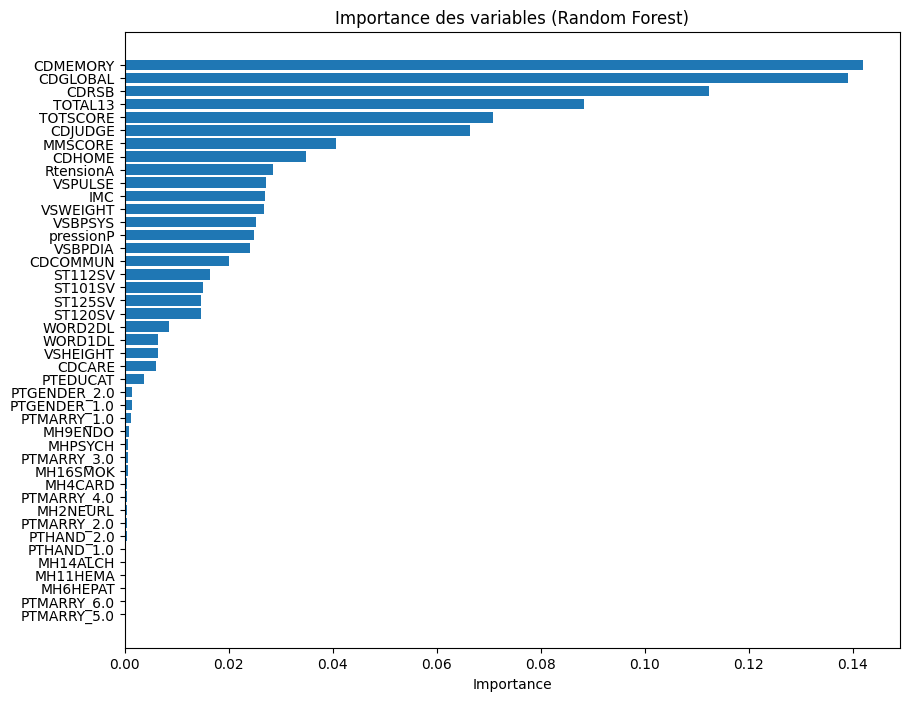

In [23]:
# Récupérer les noms des colonnes
features = X_train.columns

# Récupérer les importances
importances = model.feature_importances_

plt.figure(figsize=(10, 8))
indices = np.argsort(importances)[::-1]

plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), features[indices])
plt.xlabel("Importance")
plt.title("Importance des variables (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

## 15. Sélection des variables step 2 avec feature_importances_

In [34]:
cols_final = ["DIAGNOSIS","CDGLOBAL", "CDMEMORY", "CDRSB", "TOTSCORE", "TOTAL13", "CDJUDGE", "MMSCORE", "VSWEIGHT", "RtensionA", "VSPULSE", "CDHOME", "VSBPSYS", "pressionP", "CDCOMMUN", "VSBPDIA", "ST112SV", "ST120SV", "ST101SV", "ST125SV", "WORD2DL", "IMC"]
df = df[cols_final]
print(f'  • Réduction du nombre de variables à {df.shape[1]} avec feature_importances_')

  • Réduction du nombre de variables à 22 avec feature_importances_


In [24]:
print("Dataset après prépocessing :")
print(f'  • Dimensions: {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'  • Mémoire utilisée: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'  • Types: {df.dtypes.value_counts().to_dict()}')
print(f'  • Valeurs manquantes: {df.isnull().sum().sum():,}')

Dataset après prépocessing :
  • Dimensions: 15,532 lignes × 22 colonnes
  • Mémoire utilisée: 2.7 MB
  • Types: {dtype('float64'): 22}
  • Valeurs manquantes: 0


## 16. Sauvegarde des tables de ML

In [37]:
#sauvegarde de la nouvelle table
def save_to_supabase(df, table_name, batch_size=2000):
    if isinstance(df, pd.Series):
        df = df.to_frame()

    col = df.columns[0] 
    supabase.table(table_name).delete().gte(col, -999999999).execute()

    data = df.to_dict(orient="records")

    for i in range(0, len(data), batch_size):
        batch = data[i:i+batch_size]
        supabase.table(table_name).insert(batch).execute()
        print(f"Inséré {i+len(batch)} / {len(data)} lignes")
    print(f"**** Table {table_name} exportée {df.shape}\n")
print(f"=> Exportation en cours :")

#commande qui appel la fonction save supabase :
save_to_supabase(X_train, "X_train")
save_to_supabase(X_test, "X_test")
save_to_supabase(y_train, "y_train")
save_to_supabase(y_test, "y_test")
print(f"=> Exportation des tables train terminée")


=> Exportation en cours :
Inséré 2000 / 12425 lignes
Inséré 4000 / 12425 lignes
Inséré 6000 / 12425 lignes
Inséré 8000 / 12425 lignes
Inséré 10000 / 12425 lignes
Inséré 12000 / 12425 lignes
Inséré 12425 / 12425 lignes
**** Table X_train exportée (12425, 21)

Inséré 2000 / 3107 lignes
Inséré 3107 / 3107 lignes
**** Table X_test exportée (3107, 21)

Inséré 2000 / 12425 lignes
Inséré 4000 / 12425 lignes
Inséré 6000 / 12425 lignes
Inséré 8000 / 12425 lignes
Inséré 10000 / 12425 lignes
Inséré 12000 / 12425 lignes
Inséré 12425 / 12425 lignes
**** Table y_train exportée (12425, 1)

Inséré 2000 / 3107 lignes
Inséré 3107 / 3107 lignes
**** Table y_test exportée (3107, 1)

=> Exportation des tables train terminée


## 17. Sauvegarde des transformers

In [30]:
output_dir = "transformers" 
os.makedirs(output_dir, exist_ok=True)

# Sauvegarder les transformateurs pour prediction future
transformers = {
    'imputer_median': imputer_med,
    'imputer_mode': imputer_mode,
    'scaler': scaler,
    #'onehotencoder': encoder, plus utile car les varaibles concernées n'ont pas été selectionnées
    'feature_names': X.columns.tolist(),
    'target_name': 'DIAGNOSIS'
}

with open(f'{output_dir}/transformers.pkl', 'wb') as f:
    pickle.dump(transformers, f)

print(f'\n Transformateurs sauvegardés:')
print(f'  • transformers.pkl (ImputerMed + ImputerMode + StandardScaler )')

print(f'\n Localisation: {os.path.abspath(output_dir)}')


 Transformateurs sauvegardés:
  • transformers.pkl (ImputerMed + ImputerMode + StandardScaler + OneHotEncoder)

 Localisation: c:\Users\Magalie\donneesMagalie\formationM2i\programme python\Alzheimer_projet_jupyter\transformers


## 18. RAPPORT FINAL - PREPROCESSING COMPLET

In [32]:
print(f'\n DONNEES BRUTES:')
print(f'  • Table: ALZ_BRONZE')
print(f'  • Dimensions: {dfB.shape[0]:,} lignes × {dfB.shape[1]} colonnes')
print(f'  • Mémoire: {dfB.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'  • Valeurs manquantes: {dfB.isnull().sum().sum():,}')

print(f'\n TRANSFORMATIONS APPLIQUEES:')
print(f'  1.  Codes ADNI remplacés (-4, -1 → NaN): {nan_après - nan_avant:,} ')
print(f'  2.  Records invalides filtrés: {Filtre_ADNI+NbLigDouble+NbLigSansUnit:,} lignes supprimées')
print(f'  3.  Transforamation de la cible Sain → 0, MCI et AD → 1 ')
print(f'  4.  Variables sélectionnées: {dfB.shape[1]} → {NbVariableSOneHotEncoder-3} colonnes')
print(f'  5.  Valeurs manquantes imputées: {missing_before.sum():,} → {missing_after}')
print(f'  6.  Variables encodées: {len(nominale_cols)} (OneHotEncoder)')
print(f'  7.  Features engineered: 3 nouvelles (BMI, BP_Ratio, Pulse_Pressure)')
print(f'  8.  Variables normalisées: {len(numeric_cols)} (StandardScaler)')
print(f'  9.  Train/Test split: 80/20 stratifié')

print(f'\n DONNEES FINALES:')
print(f'  • Variables sans OneHotEncoder : {NbVariableSOneHotEncoder}')
print(f'  • Variables avec OneHotEncoder : 44')
print(f'  • Variables après feature_importances_ : {df.shape[1]}')
print(f'  • Train set: {X_train.shape[0]:,} échantillons')
print(f'  • Test set: {X_test.shape[0]:,} échantillons')
print(f'  • Total: {X_train.shape[0] + X_test.shape[0]:,} échantillons')
print(f'  • Ratio: {(len(X_train)/(len(X_train)+len(X_test))*100):.0f}% train / {(len(X_test)/(len(X_train)+len(X_test))*100):.0f}% test')

print(f'\n CLASSES (Distribution):')
print(f'  Train:')
for cls in sorted(y_train.unique()):
    count = (y_train == cls).sum()
    pct = count / len(y_train) * 100
    bar = '█' * int(pct/2)
    print(f'    Classe {int(cls)}: {count:>5,} ({pct:>5.1f}%) {bar}')
print(f'  Test:')
for cls in sorted(y_test.unique()):
    count = (y_test == cls).sum()
    pct = count / len(y_test) * 100
    bar = '█' * int(pct/2)
    print(f'    Classe {int(cls)}: {count:>5,} ({pct:>5.1f}%) {bar}')

print(f'\n Tables EXPORTES:')
print(f'  • X_train')
print(f'  • X_test')
print(f'  • y_train')
print(f'  • y_test')

print(f'  • Transformer crée : transformers.pkl')

print(f'\n Localisation: SUPABASE\public')

print(f'\n' + '='*80)
print(f' PREPROCESSING TERMINE AVEC SUCCES')
print(f' Data prête pour la modélisation ML')
print(f'='*80)



 DONNEES BRUTES:
  • Table: ALZ_BRONZE
  • Dimensions: 15,987 lignes × 584 colonnes
  • Mémoire: 99.5 MB
  • Valeurs manquantes: 5,095,662

 TRANSFORMATIONS APPLIQUEES:
  1.  Codes ADNI remplacés (-4, -1 → NaN): 84,415 
  2.  Records invalides filtrés: 455 lignes supprimées
  3.  Transforamation de la cible Sain → 0, MCI et AD → 1 
  4.  Variables sélectionnées: 584 → 34 colonnes
  5.  Valeurs manquantes imputées: 246,556 → 0
  6.  Variables encodées: 3 (OneHotEncoder)
  7.  Features engineered: 3 nouvelles (BMI, BP_Ratio, Pulse_Pressure)
  8.  Variables normalisées: 22 (StandardScaler)
  9.  Train/Test split: 80/20 stratifié

 DONNEES FINALES:
  • Variables sans OneHotEncoder : 37
  • Variables avec OneHotEncoder : 44
  • Variables après feature_importances_ : 22
  • Train set: 12,425 échantillons
  • Test set: 3,107 échantillons
  • Total: 15,532 échantillons
  • Ratio: 80% train / 20% test

 CLASSES (Distribution):
  Train:
    Classe 0: 4,844 ( 39.0%) ███████████████████
    Class